In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

X_train = pd.read_pickle('../data/processed/tree_ready/X_train.pkl')
X_test = pd.read_pickle('../data/processed/tree_ready/X_test.pkl')
y_test = pd.read_pickle('../data/processed/tree_ready/y_test.pkl')

X_train_scaled = pd.read_pickle('../data/processed/neural_ready/X_train.pkl')
X_test_scaled = pd.read_pickle('../data/processed/neural_ready/X_test.pkl')

with open('../models/ml/xgboost.pkl', 'rb') as f:
    best_xgb = pickle.load(f)
with open('../models/ml/random_forest.pkl', 'rb') as f:
    best_rf = pickle.load(f)
with open('../models/ml/lightgbm.pkl', 'rb') as f:
    best_lgbm = pickle.load(f)
with open('../models/ml/logistic_regression.pkl', 'rb') as f:
    log_reg = pickle.load(f)
with open('../models/ml/svm.pkl', 'rb') as f:
    svm = pickle.load(f)

interpretation_log = []

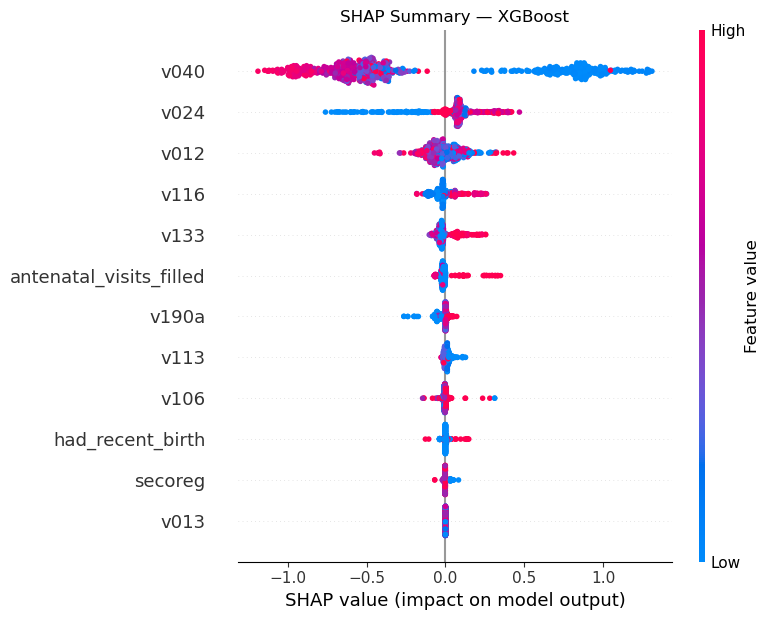

In [2]:
explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, show=False)
plt.title('SHAP Summary — XGBoost')
plt.tight_layout()
plt.show()

In [3]:
mean_abs_shap = np.abs(shap_values_xgb).mean(axis=0)
top_features_xgb = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=False)

md = f"""### SHAP Explainability — XGBoost (Primary Model)

**Observations:**
- Top 3 features by mean |SHAP value|: {', '.join(top_features_xgb.head(3).index.tolist())}
- This ranking {"aligns with" if top_features_xgb.index[0] == 'v040' else "differs from"} the permutation importance finding in notebook 08, where v040 (altitude) was the dominant feature.

**Implication:**
- SHAP confirms which features drive individual predictions, not just aggregate model performance — useful for explaining why a specific woman was flagged as high-risk.
"""
display(Markdown(md))
interpretation_log.append(md)

### SHAP Explainability — XGBoost (Primary Model)

**Observations:**
- Top 3 features by mean |SHAP value|: v040, v024, v012
- This ranking aligns with the permutation importance finding in notebook 08, where v040 (altitude) was the dominant feature.

**Implication:**
- SHAP confirms which features drive individual predictions, not just aggregate model performance — useful for explaining why a specific woman was flagged as high-risk.


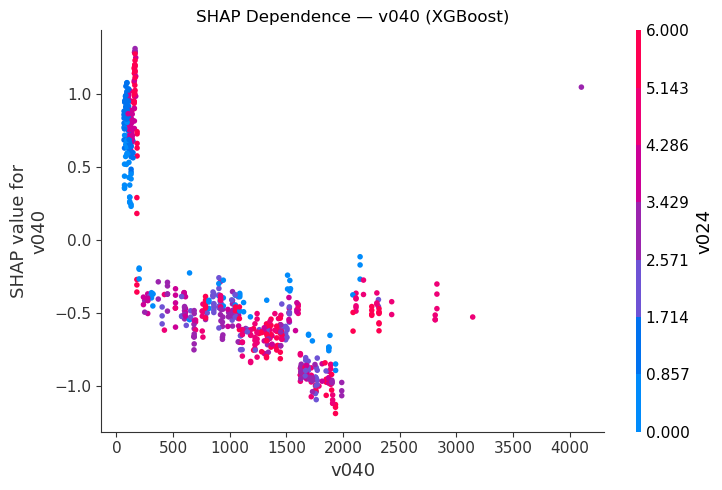

In [5]:
top_feature = top_features_xgb.index[0]
shap.dependence_plot(top_feature, shap_values_xgb, X_test, show=False)
plt.title(f'SHAP Dependence — {top_feature} (XGBoost)')
plt.tight_layout()
plt.show()

Shape used for plotting: (675, 12)


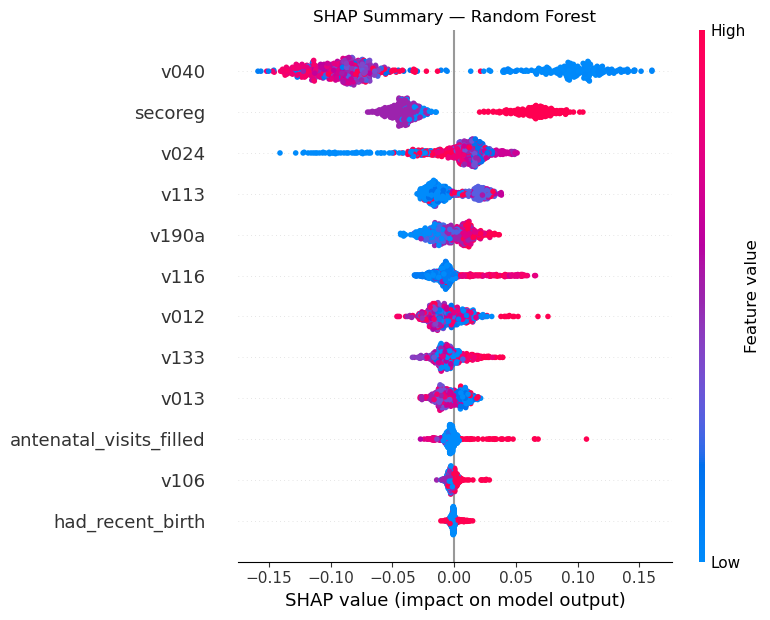

### SHAP Explainability — Random Forest

**Observations:**
- Top 3 features: v040, secoreg, v024
- Top feature overlap with XGBoost: 2 of top 5 features shared.

**Implication:**
- Some divergence between models suggests feature importance may be sensitive to model architecture — worth discussing as a limitation.


In [8]:
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(X_test)

# Handle all possible SHAP output shapes across versions:
# - list of 2 arrays (older shap): [class0_array, class1_array]
# - 3D array (newer shap): (n_samples, n_features, n_classes)
# - 2D array (already single-class): (n_samples, n_features)
if isinstance(shap_values_rf, list):
    shap_values_rf_pos = shap_values_rf[1]
elif shap_values_rf.ndim == 3:
    shap_values_rf_pos = shap_values_rf[:, :, 1]
else:
    shap_values_rf_pos = shap_values_rf

print("Shape used for plotting:", shap_values_rf_pos.shape)

shap.summary_plot(shap_values_rf_pos, X_test, show=False)
plt.title('SHAP Summary — Random Forest')
plt.tight_layout()
plt.show()

top_features_rf = pd.Series(np.abs(shap_values_rf_pos).mean(axis=0), index=X_test.columns).sort_values(ascending=False)

md = f"""### SHAP Explainability — Random Forest

**Observations:**
- Top 3 features: {', '.join(top_features_rf.head(3).index.tolist())}
- Top feature overlap with XGBoost: {len(set(top_features_xgb.head(5).index) & set(top_features_rf.head(5).index))} of top 5 features shared.

**Implication:**
- {"Strong agreement across tree-based models increases confidence these features are genuinely predictive, not model-specific artifacts." if len(set(top_features_xgb.head(5).index) & set(top_features_rf.head(5).index)) >= 3 else "Some divergence between models suggests feature importance may be sensitive to model architecture — worth discussing as a limitation."}
"""
display(Markdown(md))
interpretation_log.append(md)

c:\Users\Suvekshya\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


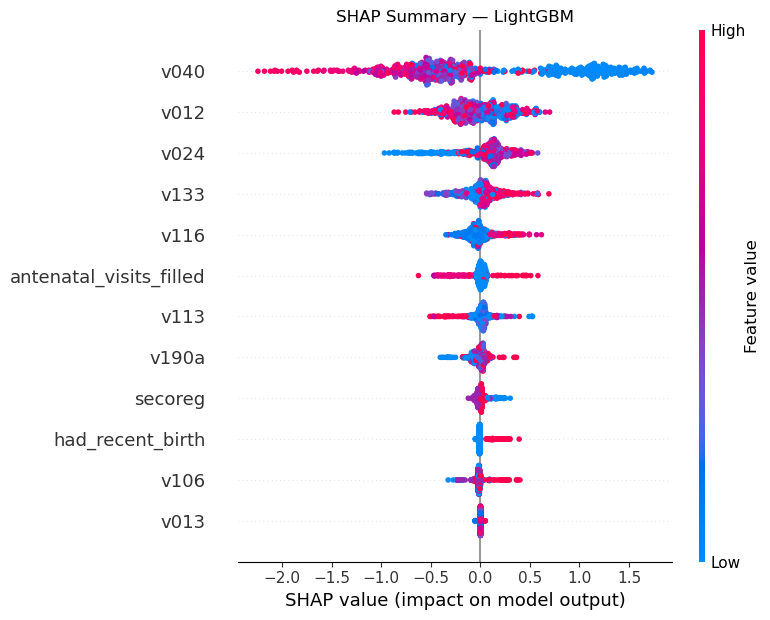

### SHAP Explainability — LightGBM

**Observations:**
- Top 3 features: v040, v012, v024


In [10]:
explainer_lgbm = shap.TreeExplainer(best_lgbm)
shap_values_lgbm = explainer_lgbm.shap_values(X_test)

if isinstance(shap_values_lgbm, list):
    shap_values_lgbm_pos = shap_values_lgbm[1]
elif shap_values_lgbm.ndim == 3:
    shap_values_lgbm_pos = shap_values_lgbm[:, :, 1]
else:
    shap_values_lgbm_pos = shap_values_lgbm

shap.summary_plot(shap_values_lgbm_pos, X_test, show=False)
plt.title('SHAP Summary — LightGBM')
plt.tight_layout()
plt.show()

top_features_lgbm = pd.Series(np.abs(shap_values_lgbm_pos).mean(axis=0), index=X_test.columns).sort_values(ascending=False)

md = f"""### SHAP Explainability — LightGBM

**Observations:**
- Top 3 features: {', '.join(top_features_lgbm.head(3).index.tolist())}
"""
display(Markdown(md))
interpretation_log.append(md)

Background dataset has 2696 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2696 when initializing the masker.


TypeError: loop of ufunc does not support argument 0 of type float which has no callable rint method

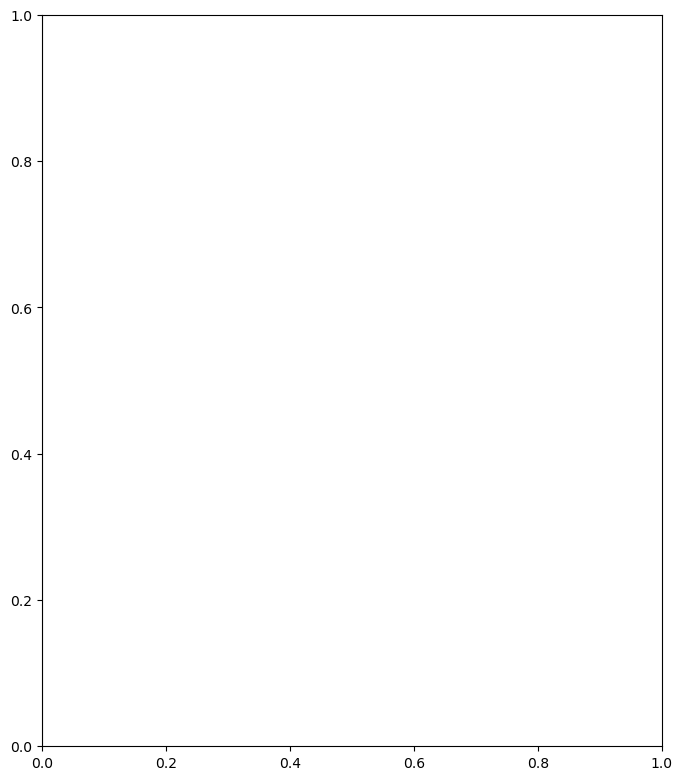

In [12]:
explainer_lr = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled)

shap.summary_plot(shap_values_lr, X_test_scaled, show=False)
plt.title('SHAP Summary — Logistic Regression')
plt.tight_layout()
plt.show()

top_features_lr = pd.Series(np.abs(shap_values_lr).mean(axis=0), index=X_test_scaled.columns).sort_values(ascending=False)

md = f"""### SHAP Explainability — Logistic Regression

**Observations:**
- Top 3 features: {', '.join(top_features_lr.head(3).index.tolist())}

**Implication:**
- Since Logistic Regression is linear, SHAP values here directly reflect each feature's coefficient-weighted contribution — a useful, more transparent cross-check against the tree-based models' nonlinear explanations.
"""
display(Markdown(md))
interpretation_log.append(md)

In [ ]:
background = shap.sample(X_train_scaled.astype(float), 50, random_state=42)
test_sample = X_test_scaled.astype(float).sample(100, random_state=42)

explainer_svm = shap.KernelExplainer(svm.predict_proba, background)
shap_values_svm = explainer_svm.shap_values(test_sample, nsamples=100)

if isinstance(shap_values_svm, list):
    shap_values_svm_pos = shap_values_svm[1]
elif np.array(shap_values_svm).ndim == 3:
    shap_values_svm_pos = np.array(shap_values_svm)[:, :, 1]
else:
    shap_values_svm_pos = shap_values_svm

shap.summary_plot(shap_values_svm_pos, test_sample, show=False)
plt.title('SHAP Summary — SVM (subsampled)')
plt.tight_layout()
plt.show()

top_features_svm = pd.Series(np.abs(shap_values_svm_pos).mean(axis=0), index=test_sample.columns).sort_values(ascending=False)

md = f"""### SHAP Explainability — SVM (Best Recall Model)

**Observations:**
- Top 3 features: {', '.join(top_features_svm.head(3).index.tolist())}
- Note: computed on a 100-row test subsample (of {len(X_test_scaled)} total) due to KernelExplainer's computational cost — treat as directionally indicative rather than exhaustive.

**Implication:**
- SVM achieved the best recall of all models; understanding what drives its predictions is valuable even though its explanation is less precise than the tree-based SHAP results.
"""
display(Markdown(md))
interpretation_log.append(md)

In [ ]:
comparison = pd.DataFrame({
    'XGBoost': top_features_xgb,
    'RandomForest': top_features_rf,
    'LightGBM': top_features_lgbm,
    'LogisticRegression': top_features_lr,
    'SVM': top_features_svm
}).fillna(0)

comparison_norm = comparison / comparison.max()

plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(comparison_norm, annot=False, cmap='YlOrRd')
plt.title('Normalized Feature Importance Across Models (SHAP)')
plt.tight_layout()
plt.show()

comparison.to_csv('../results/metrics/shap_importance_comparison.csv')

md_final = f"""### Cross-Model SHAP Comparison

**Observations:**
- Features consistently important across most/all models: {', '.join(comparison_norm.mean(axis=1).sort_values(ascending=False).head(3).index.tolist())}
- This cross-model agreement is the strongest evidence for which features are genuinely predictive of anemia risk in this rural Nepali population, versus being artifacts of any single algorithm's structure.

**Implication for the study's core contribution:**
- These consistently important features should be the focus of the discussion section — both as model-driven insights and as candidates for real-world screening/intervention prioritization.
"""
display(Markdown(md_final))
interpretation_log.append(md_final)

In [ ]:
output_path = '../data/processed/explainability_interpretation.txt'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write('\n\n---\n\n'.join(interpretation_log))
print(f"Saved to {output_path}")